<div style="background:linear-gradient(135deg,#4c0519 0%,#be123c 55%,#fb7185 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fecdd3;font-weight:700;text-transform:uppercase">Chapter 158 &middot; Data Ethics, Bias &amp; Fairness &middot; Notebook 1 of 2</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Measuring Bias and Fairness</div>
  <div style="font-size:15px;color:#ffe4e6;max-width:760px;line-height:1.6">Fairness is not a feeling; it is a set of numbers you can compute. We train a lending model that never sees the protected attribute, then measure whether it treats two groups equally, by selection rate, by error rates, and by calibration, and watch a 'blind' model fail anyway.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
ROSE, BL, GR, RD, MUT = "#be123c", "#2563eb", "#16a34a", "#dc2626", "#94a3b8"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "data-ethics--lending.xlsx"
try: df = pd.read_excel("../../data/" + fn, sheet_name="applicants")
except FileNotFoundError: df = pd.read_excel(BASE + fn, sheet_name="applicants")
# NOTE: the protected attribute 'group' is deliberately NOT a model input ("fairness through unawareness").
FEAT = ["income_k", "debt_to_income", "credit_history_years", "prior_defaults"]
Xtr, Xte, ytr, yte, gtr, gte = train_test_split(df[FEAT], df.repaid, df.group, test_size=0.4, random_state=1, stratify=df.group)
clf = LogisticRegression(max_iter=1000).fit(Xtr, ytr)
te = pd.DataFrame({"group": gte.values, "repaid": yte.values, "p": clf.predict_proba(Xte)[:,1]})
te["approved"] = (te.p >= 0.5).astype(int)
A, Bg = te[te.group=="A"], te[te.group=="B"]
print("test set:", len(te), "| group A", len(A), "| group B", len(Bg))

test set: 1600 | group A 1089 | group B 511


## Step 1 &middot; The data reflects an unequal world
Before the model, look at the groups. Group B is structurally disadvantaged: lower income, higher debt ratio, shorter credit history. Crucially, the repayment label depends only on these financial features, with no direct penalty for being in group B. The disadvantage is already baked into the inputs.

actual repayment rate by group:
group
A    0.585
B    0.397

feature averages by group:
       income_k  debt_to_income  credit_history_years  prior_defaults
group                                                                
A         71.97            0.30                  8.91            0.30
B         58.15            0.36                  6.23            0.49


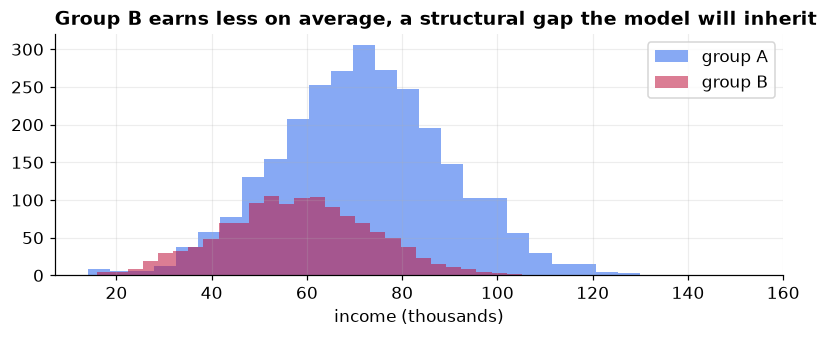

In [2]:
print("actual repayment rate by group:")
print(df.groupby("group").repaid.mean().round(3).to_string())
print("\nfeature averages by group:")
print(df.groupby("group")[FEAT].mean().round(2).to_string())
fig, ax = plt.subplots(figsize=(7.5, 3.2))
for g, col in [("A", BL), ("B", ROSE)]:
    ax.hist(df[df.group==g].income_k, bins=30, alpha=0.55, label=f"group {g}", color=col)
ax.set_title("Group B earns less on average, a structural gap the model will inherit")
ax.set_xlabel("income (thousands)"); ax.legend(); plt.tight_layout(); plt.show()

## Step 2 &middot; Selection rate and the 80% rule (demographic parity)
The most basic fairness question: does the model approve the two groups at similar rates? Demographic parity asks for equal selection rates. The US 'four-fifths rule' flags a problem when the disadvantaged group's rate is below 80 percent of the advantaged group's.

selection (approval) rate  A 73.5%   B 27.0%
disparate impact ratio B/A = 0.37   ->  fails the 80% rule: True


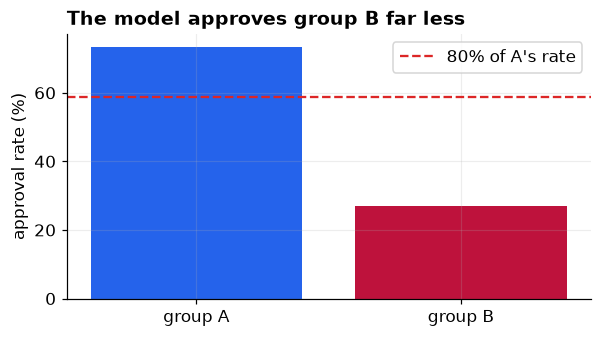

In [3]:
sel_A, sel_B = A.approved.mean(), Bg.approved.mean()
di = sel_B / sel_A
print(f"selection (approval) rate  A {sel_A:.1%}   B {sel_B:.1%}")
print(f"disparate impact ratio B/A = {di:.2f}   ->  fails the 80% rule: {di < 0.80}")
fig, ax = plt.subplots(figsize=(5.6, 3.2))
ax.bar(["group A","group B"], [sel_A*100, sel_B*100], color=[BL, ROSE])
ax.axhline(sel_A*80, color=RD, ls="--", lw=1.5, label="80% of A's rate")
ax.set_ylabel("approval rate (%)"); ax.set_title("The model approves group B far less"); ax.legend()
plt.tight_layout(); plt.show()

## Step 3 &middot; Error rates by group (equal opportunity)
Equal selection rates are only one notion. Equal opportunity asks a sharper question: among people who would actually repay, are the two groups approved at the same rate? That is the true positive rate. A gap means the model denies deserving applicants unequally.

true positive rate (approved | would repay)   A 81.1%   B 41.1%   gap 40.0%
false positive rate (approved | would default) A 62.8%   B 17.8%


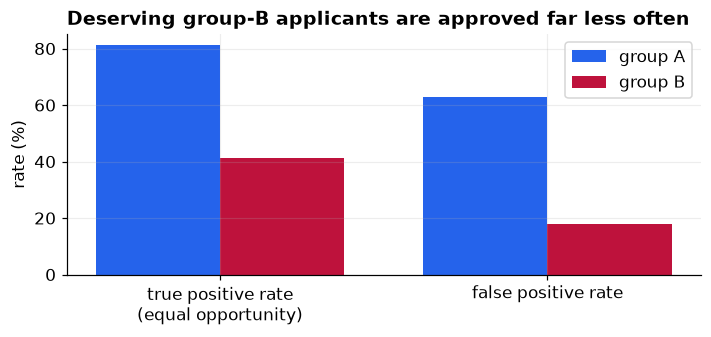

In [4]:
def tpr(s): return s[s.repaid==1].approved.mean()
def fpr(s): return s[s.repaid==0].approved.mean()
print(f"true positive rate (approved | would repay)   A {tpr(A):.1%}   B {tpr(Bg):.1%}   gap {tpr(A)-tpr(Bg):.1%}")
print(f"false positive rate (approved | would default) A {fpr(A):.1%}   B {fpr(Bg):.1%}")
x = np.arange(2); w = 0.38
fig, ax = plt.subplots(figsize=(6.6, 3.2))
ax.bar(x-w/2, [tpr(A)*100, fpr(A)*100], w, label="group A", color=BL)
ax.bar(x+w/2, [tpr(Bg)*100, fpr(Bg)*100], w, label="group B", color=ROSE)
ax.set_xticks(x, ["true positive rate\n(equal opportunity)", "false positive rate"]); ax.set_ylabel("rate (%)")
ax.set_title("Deserving group-B applicants are approved far less often"); ax.legend()
plt.tight_layout(); plt.show()

## Step 4 &middot; Calibration: the twist
Here is what makes fairness hard. Check calibration: for each group, does the average predicted probability match the actual repayment rate? If it does, the model's scores are honest for both groups, and yet, as we just saw, it still approves them unequally. A model can be perfectly calibrated and still fail demographic parity.

In [5]:
cal = te.groupby("group").agg(mean_predicted=("p","mean"), actual_repaid=("repaid","mean")).round(3)
print(cal.to_string())
print("\nThe predictions are well-calibrated for BOTH groups, yet selection and error rates differ.")
print("This is not a bug to fix; it is a mathematical fact about groups with different base rates.")

       mean_predicted  actual_repaid
group                               
A               0.588          0.583
B               0.411          0.395

The predictions are well-calibrated for BOTH groups, yet selection and error rates differ.
This is not a bug to fix; it is a mathematical fact about groups with different base rates.


### Wrap-up
The model never saw the protected attribute, yet it is measurably unfair: it fails the 80% rule and denies deserving group-B applicants far more often. 'Fairness through unawareness' does not work, because the features themselves carry the disadvantage. And the model is simultaneously well-calibrated, which means these fairness notions genuinely conflict. The next notebook confronts that conflict head-on.